In [ ]:
import dadi, numpy as np, matplotlib.pyplot as plt, demes, demesdraw, pysam, pathlib, random, json, datetime
def split_mig_model(params, ns, pts):
    import dadi
    # params = (nu_mainland, nu_island, T_iso, T_mig, m)
    nu_mainland, nu_island, T_iso, T_mig, m = params

    xx = dadi.Numerics.default_grid(pts)
    deme_ids = ('Mainland', 'Island')

    # Equilibrium → split to 2D with stable deme labels (good for CUDA)
    phi = dadi.PhiManip.phi_1D(xx, deme_ids=(deme_ids[0],))
    phi = dadi.PhiManip.phi_1D_to_2D(xx, phi, deme_ids=deme_ids)

    # Isolation epoch (no migration)
    if T_iso > 0:
        phi = dadi.Integration.two_pops(
            phi, xx, T_iso, nu_mainland, nu_island, deme_ids=deme_ids
        )

    # Secondary contact epoch (symmetric migration)
    if T_mig > 0:
        phi = dadi.Integration.two_pops(
            phi, xx, T_mig, nu_mainland, nu_island,
            m12=m, m21=m, deme_ids=deme_ids
        )

    return dadi.Spectrum.from_phi(phi, ns, (xx, xx), mask_corners=True)



False

In [5]:
import pycuda.driver as drv
drv.init()
print("Device count:", drv.Device.count())
print("First device:", drv.Device(0).name())
ctx = drv.Device(0).make_context()
ctx.pop()
import skcuda.cublas as cublas
handle = cublas.cublasCreate()
cublas.cublasDestroy(handle)
import dadi
dadi.cuda_enabled(False)


Device count: 1
First device: NVIDIA A100-SXM4-40GB


False

In [34]:
import pathlib
import pysam
import dadi

# ── User inputs ──────────────────────────────────────────────────────
VCF = pathlib.Path(
    "/nas/longleaf/home/adaigle/johri/projects/ghist_2025/data/demography/"
    "GHIST_2025_secondary_contact.testing.fixedheader.vcf.gz"
)
#VCF = pathlib.Path(
#    "/nas/longleaf/home/adaigle/users/ghist_2025/test_sims/"
#    "split_recontact/replicate_2.nuc.withAA.vcf"
#)
#VCF = pathlib.Path(
#    "/nas/longleaf/home/adaigle/johri/projects/ghist_2025/data/demography/"
#    "GHIST_2025_secondary_contact.final.vcf.gz"
#)
REGION_LENGTH = 100_000_000  # total callable bases
pop_ids       = ["mainland", "island"]
ns            = [48, 22]     # diploid sample sizes

# ── 1) make a .popfile.txt if needed ────────────────────────────────
popfile = VCF.with_suffix(".popfile.txt")
if not popfile.exists():
    with popfile.open("w") as fh:
        for sample in pysam.VariantFile(str(VCF)).header.samples:
            pop = sample.split("_", 1)[0]
            fh.write(f"{sample}\t{pop}\n")

# ── 2) build data-dict & raw SFS (unmasked corners) ─────────────────
dd = dadi.Misc.make_data_dict_vcf(str(VCF), str(popfile))
fs = dadi.Spectrum.from_data_dict(
    dd, pop_ids, ns,
    polarized=True,       # or False if you want folded
    mask_corners=False,   # allow corner bins to be unmasked
)

# ── 3) inject monomorphic sites into [0,0] ─────────────────────────
observed_sites = fs.sum()
mono = REGION_LENGTH - observed_sites
fs[0, 0] += mono

# ── 4) explicitly unmask the corners you care about ────────────────
fs.mask[0, 0]   = True   # invariant
fs.mask[-1, -1] = True   # fixed-derived
fs.mask[0, -1]  = True  # private-derived on island
fs.mask[-1, 0]  = True  # private-derived on mainland

# ── 5) sanity checks ────────────────────────────────────────────────
print("Total sites in fs:", fs.sum(), "(should equal REGION_LENGTH)")
print(fs)


Total sites in fs: 3110757.0 (should equal REGION_LENGTH)
[[-- 536033.0 100403.0 ... 0.0 0.0 --]
 [513465.0 77113.0 30781.0 ... 0.0 0.0 0.0]
 [201740.0 48764.0 22109.0 ... 0.0 0.0 0.0]
 ...
 [0.0 0.0 0.0 ... 1748.0 2022.0 2438.0]
 [0.0 0.0 0.0 ... 1821.0 2353.0 3024.0]
 [-- 0.0 0.0 ... 2274.0 4524.0 --]]


In [5]:
print(f"Shared fixed = {fs[-1,-1]}, Private fixed = {fs[-1,0] + fs[0,-1]}, Monomorphic = {fs[0,0]}")

Shared fixed = 2629.0, Private fixed = 0.0, Monomorphic = 94801856.0


In [4]:
#make sure 0,0 is unmasked when you save this!

out_file = "/nas/longleaf/home/adaigle/johri/projects/ghist_2025/intermediate_files/GHIST2025_secondary_contact_testing_jointSFS.obs"
#out_file = "/nas/longleaf/home/adaigle/johri/projects/ghist_2025/intermediate_files/GHIST2025_secondary_contact_final_jointSFS.obs"


# 0) Make absolutely sure no bins are masked
fs.mask[:] = False

# 1) Grab the integer matrix
mat = fs.data.astype(int)

# 2) Write out for fastsimcoal2
n0, n1 = ns

with open(out_file, "w") as fh:
    fh.write("1 observations\n")
    fh.write(" ".join(f"d0_{j}" for j in range(n0+1)) + "\n")
    for i in range(n1+1):
        counts = [str(mat[j, i]) for j in range(n0+1)]
        fh.write(" ".join([f"d1_{i}"] + counts) + "\n")

print(f"Wrote 2D‐SFS for fastsimcoal2 to {out_file}")



Wrote 2D‐SFS for fastsimcoal2 to /nas/longleaf/home/adaigle/johri/projects/ghist_2025/intermediate_files/GHIST2025_secondary_contact_testing_jointSFS.obs


In [6]:
# ── 1) FSC2 estimates ─────────────────────────────────────────────────
Ncurr1   = 288_739.0    # pop 1 current size
Ncurr2   = 596_064.0    # pop 2 current size
Tcontact = 15_402.0     # generations since secondary contact
Tsplit   = 96_652.0     # generations since split
Nanc     = 290_300.0    # ancestral size
m12_fsc  = 1.20221e-05  # per‐gen. rate into pop1
m21_fsc  = 1.27395e-05  # per‐gen. rate into pop2

# ── 2) Convert to Dadi “nu”’s and times (in 2Nref units) ───────────────
nu1   = Ncurr1 / Nanc
nu2   = Ncurr2 / Nanc

T_tot = Tsplit   / (2 * Nanc)     # split time in coalescent units
T_mig = Tcontact / (2 * Nanc)     # secondary‐contact time in same units

# ── 3) Convert per‐gen m’s to Dadi’s scaled m = 2*Nref*m_fsc (we’ll average)
m_scaled = 2 * Nanc * (m12_fsc + m21_fsc) / 2

# ── 4) Pack into your Dadi initial‐guess vector ────────────────────────
p0 = [nu1, nu2, T_tot, T_mig, m_scaled]

print("Dadi initial p0:", p0)


Dadi initial p0: [0.9946228039958663, 2.053269032035825, 0.16646916982431967, 0.026527729934550465, 7.18829248]


In [6]:
from scipy.optimize import differential_evolution

# Define the sample sizes
ns = fs.sample_sizes

# Grid points for numerical integration
pts_l = [50, 60, 70]
# Wrap for extrapolation and log-space optimization (standard practice)
func = dadi.Numerics.make_extrap_log_func(split_mig_model)

# Reasonable bounds: sizes in [1e-2, 1e2], times in (1e-4, ~a few),
# migration in [1e-5, 10] (tune to your data)
lower_bound = [1e-2, 1e-2, 1e-4, 1e-4, 1e-5]
upper_bound = [1e2,  1e2,  5.0,  5.0,  10.0]

# Start near 1 for sizes, modest durations, small m
p0 = [1.0, 1.0, 0.1, 0.05, 0.1]

# Generate the model SFS
func = dadi.Numerics.make_extrap_log_func(split_mig_model)

initial_guesses = [
    #[0.9946228039958663, 2.053269032035825, 0.16646916982431967, 0.026527729934550465, 7.18829248],
    [1.0, 1.0, 1, 0.005, 0.1],
    [2.0, 0.5, 0.5, 0.01, 0.05],
    [0.5, 2.0, 0.1, 0.02, 0.01],
    [1.5, 1.5, 0.2, 0.005, 0.02]
]

best_popt = None
best_ll = -float("inf")

for p0 in initial_guesses:
    try:
        popt = dadi.Inference.optimize_log(
            p0, fs, func, pts_l, lower_bound=lower_bound, upper_bound=upper_bound
        )
        model = func(popt, ns, pts_l)
        ll_model = dadi.Inference.ll_multinom(model, fs)
        if ll_model > best_ll:
            best_ll = ll_model
            best_popt = popt
        print(f"Log-likelihood for initial guess {p0}: {ll_model}")
    except ValueError as e:
        print("Error during optimization:", e)

print("Best parameters after multiple initializations:", best_popt)

popt=best_popt

Log-likelihood for initial guess [1.0, 1.0, 1, 0.005, 0.1]: -466203.9444306017
Log-likelihood for initial guess [2.0, 0.5, 0.5, 0.01, 0.05]: -432375.34326437087
Log-likelihood for initial guess [0.5, 2.0, 0.1, 0.02, 0.01]: -83759.95164049458
Log-likelihood for initial guess [1.5, 1.5, 0.2, 0.005, 0.02]: -47028.850329746274
Best parameters after multiple initializations: [0.99599912 1.98569427 0.14439137 0.03491738 6.172522  ]


In [6]:
# Given parameters from your dadi analysis
# Mutation rate (per generation per base pair)
mu = 8.4e-8

# Size of genomic region sequenced (in base pairs)
#L = 100_000_000
L = 100_000_000

# Generation time (in years)
generation_time = 1

# Calculate theta from optimized model
model_fs = func(popt, ns, pts_l)
theta = dadi.Inference.optimal_sfs_scaling(model_fs, fs)
print(f"Real theta (θ): {theta:.5f}")

N_a = theta / (4 * mu * L)
nu_mainland, nu_island, T_iso, T_mig, m = popt
N_mainland = nu_mainland * N_a
N_island   = nu_island   * N_a

T_split_gen = (T_iso + T_mig) * 2 * N_a       # split time before present
T_mig_gen   =  T_mig        * 2 * N_a         # contact start before present

m_per_gen = m / (2 * N_a)

# Convert time in generations to time in years
T_split_years = T_split_gen * generation_time
T_mig_years = T_mig_gen * generation_time

# Print the results
print(f"Ancestral population size (N_a): {N_a:.2f}")
print(f"Mainland population size (N_mainland): {N_mainland:.2f}")
print(f"Island population size (N_island): {N_island:.2f}")
print(f"Time of split in generations: {T_split_gen:.2f}")
print(f"Time of split in years: {T_split_years:.2f}")
print(f"Time of secondary contact in generations: {T_mig_gen:.2f}")
print(f"Time of secondary contact in years: {T_mig_years:.2f}")
print(f"Migration rate (m_scaled) for demes: {m_per_gen:.9f}")


Real theta (θ): 463076.88268
Ancestral population size (N_a): 13782.05
Mainland population size (N_mainland): 13726.91
Island population size (N_island): 27366.94
Time of split in generations: 4942.48
Time of split in years: 4942.48
Time of secondary contact in generations: 962.47
Time of secondary contact in years: 962.47
Migration rate (m_scaled) for demes: 0.000223933


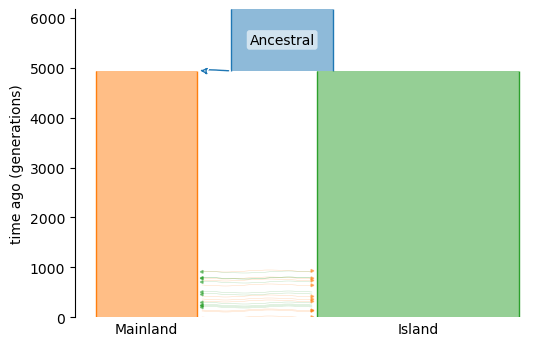

In [7]:
import matplotlib.pyplot as plt
import demes
import demesdraw

# Define the demographic model using a YAML string format, with one-way migration
yaml_model = f"""
description: Split with secondary contact and one-way migration
time_units: generations
demes:
  - name: Ancestral
    start_time: .inf
    epochs:
      - end_time: {T_split_gen:.2f}
        start_size: {N_a:.2f}

  - name: Mainland
    start_time: {T_split_gen:.2f}
    ancestors: [Ancestral]
    epochs:
      - end_time: {T_mig_gen:.2f}
        start_size: {N_mainland:.2f}
      - end_time: 0
        start_size: {N_mainland:.2f}

  - name: Island
    start_time: {T_split_gen:.2f}
    ancestors: [Ancestral]
    epochs:
      - end_time: {T_mig_gen:.2f}
        start_size: {N_island:.2f}
      - end_time: 0
        start_size: {N_island:.2f}

migrations:
  - source: Mainland
    dest: Island
    start_time: {T_mig_gen:.2f}
    end_time: 0
    rate: {m_per_gen:.9f}  # Ensure m_scaled is within [0, 1]
  - source: Island
    dest: Mainland
    start_time: {T_mig_gen:.2f}
    end_time: 0
    rate: {m_per_gen:.9f}  # Ensure m_scaled is within [0, 1]
"""

# Load the YAML model into a demes graph object
graph = demes.loads(yaml_model)

# Visualize the model
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
demesdraw.tubes(graph, ax=ax)
plt.show()


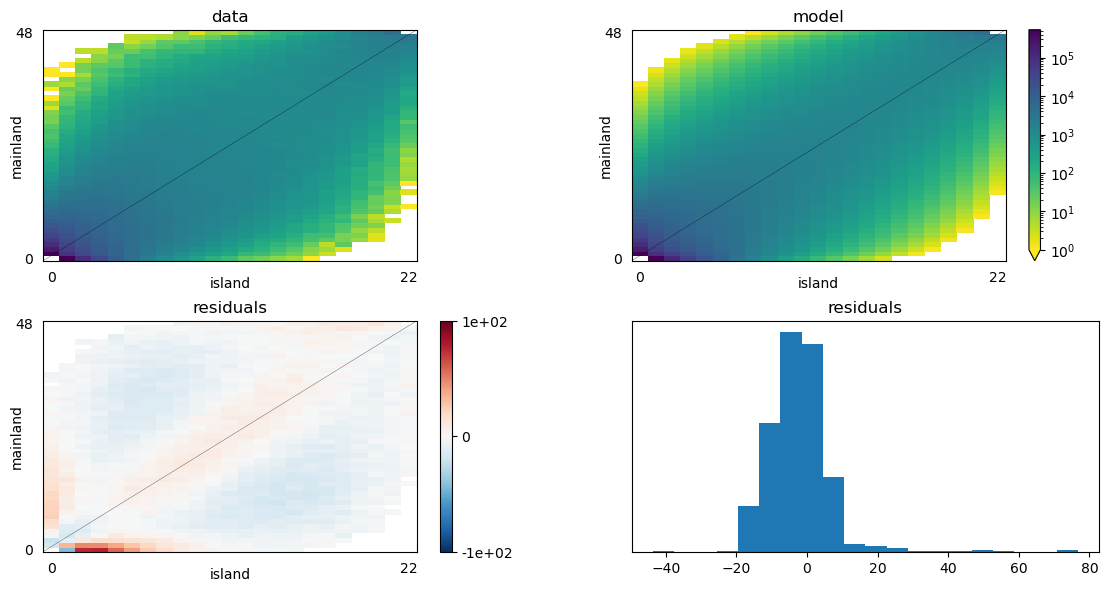

In [8]:
import dadi
import matplotlib.pyplot as plt

# Assuming `fs` is your observed frequency spectrum from the real data
# Assuming `popt` are the optimized parameters from the inferred model

# 1. Generate the model frequency spectrum using the optimized parameters
# Your demographic model function should be already defined (e.g., split_no_mig_model)
model = func(popt, fs.sample_sizes, pts_l)

# 2. Plot the comparison between the observed and model frequency spectrum
fig = plt.figure(figsize=(12, 6))

# Use dadi's plotting function to compare the observed and model FS
dadi.Plotting.plot_2d_comp_multinom(model, fs, vmin=1, resid_range=100)

plt.show()

In [17]:
def split_mig_sym_exp_indep(params, ns, pts):
    """
    Symmetric migration, independent size-change start times.

    params = (nuM0, nuI0, nuM1, nuI1, T_iso, T_mig, f1, f2, m)
      - nuM0,nuI0 : sizes in isolation and at contact start
      - nuM1,nuI1 : present-day sizes
      - T_iso     : isolation duration (split→contact)
      - T_mig     : contact duration (contact→present)
      - f1,f2     : fractions in [0,1] when each deme begins changing within contact
      - m         : symmetric migration during contact
    """
    import numpy as np
    import dadi

    (nuM0, nuI0, nuM1, nuI1, T_iso, T_mig, f1, f2, m) = params
    eps = 1e-8
    T_iso = max(T_iso, eps)
    T_mig = max(T_mig, eps)

    # Clamp fractions and convert to “time since contact start”
    f1 = min(max(f1, 0.0), 1.0)
    f2 = min(max(f2, 0.0), 1.0)
    t1 = f1 * T_mig                 # Mainland change begins t1 before present
    t2 = f2 * T_mig                 # Island change begins t2 before present
    startM = T_mig - t1             # time since contact start when Mainland starts changing
    startI = T_mig - t2

    xx = dadi.Numerics.default_grid(pts)
    deme_ids = ('Mainland', 'Island')

    # --- CUDA hint: set deme_ids globally for the CUDA backend
    try:
        import dadi.cuda as _dc
        _dc.Integration.deme_ids = deme_ids
    except Exception:
        pass

    # Build phi
    phi = dadi.PhiManip.phi_1D(xx, deme_ids=(deme_ids[0],))
    phi = dadi.PhiManip.phi_1D_to_2D(xx, phi, deme_ids=deme_ids)

    # 1) Isolation (constant sizes, no migration)
    phi = dadi.Integration.two_pops(phi, xx, T_iso, nuM0, nuI0, deme_ids=deme_ids)

    # Helper for exponential schedule
    def _exp_lambda(s0, s1, total_dur):
        if total_dur <= eps:
            return (lambda t, v=s0: v)
        g = np.log(max(s1, eps) / max(s0, eps))
        if abs(g) < 1e-12:
            return (lambda t, v=s0: v)
        return lambda t, s0=s0, g=g, total_dur=total_dur: s0 * np.exp(g * (t / total_dur))

    # Segment the contact epoch, clamp to nonnegative
    smin = max(min(startM, startI), 0.0)
    smax = max(startM, startI)
    smax = min(max(smax, 0.0), T_mig)

    d0 = max(smin, 0.0)                  # before any change
    d1 = max(smax - smin, 0.0)           # first deme changing
    d2 = max(T_mig - smax, 0.0)          # both possibly changing

    # 2) Contact segment 1: both constant
    if d0 > eps:
        phi = dadi.Integration.two_pops(
            phi, xx, d0, nuM0, nuI0, m12=m, m21=m, deme_ids=deme_ids
        )

    # Track sizes at current boundary
    curM, curI = nuM0, nuI0

    # 3) Contact segment 2: whichever starts first
    if d1 > eps:
        if startM < startI:
            T_remain_M = max(t1, 0.0)
            nuM_seg2 = _exp_lambda(curM, nuM1, max(T_remain_M, eps))
            phi = dadi.Integration.two_pops(
                phi, xx, d1, nu1=nuM_seg2, nu2=(lambda t, v=curI: v),
                m12=m, m21=m, deme_ids=deme_ids
            )
            # update Mainland size at the boundary
            curM = nuM_seg2(d1)
        else:
            T_remain_I = max(t2, 0.0)
            nuI_seg2 = _exp_lambda(curI, nuI1, max(T_remain_I, eps))
            phi = dadi.Integration.two_pops(
                phi, xx, d1, nu1=(lambda t, v=curM: v), nu2=nuI_seg2,
                m12=m, m21=m, deme_ids=deme_ids
            )
            curI = nuI_seg2(d1)

    # 4) Contact segment 3: both changing (or one continues)
    if d2 > eps:
        if startM < startI:
            T_left_M = max(t1 - d1, 0.0)   # remaining time for Mainland’s exp
            T_left_I = max(t2, 0.0)        # Island starts now
        else:
            T_left_I = max(t2 - d1, 0.0)
            T_left_M = max(t1, 0.0)
        nuM_seg3 = _exp_lambda(curM, nuM1, max(T_left_M, eps))
        nuI_seg3 = _exp_lambda(curI, nuI1, max(T_left_I, eps))
        phi = dadi.Integration.two_pops(
            phi, xx, d2, nu1=nuM_seg3, nu2=nuI_seg3,
            m12=m, m21=m, deme_ids=deme_ids
        )

    return dadi.Spectrum.from_phi(phi, ns, (xx, xx))


In [18]:
import numpy as np, dadi
import matplotlib.pyplot as plt
dadi.cuda_enabled(True)

# ---- grid: a bit larger than max sample size
nmax = int(np.max(fs.sample_sizes))
pts_l = [nmax + 15, nmax + 25, nmax + 35]

# ---- wrap to match data mask/fold
def model_for_opt(params, ns, pts):
    mfs = split_mig_sym_exp_indep(params, ns, pts)
    if fs.folded and not mfs.folded:
        mfs = mfs.fold()
    mfs.mask = fs.mask.copy()
    return mfs

func = dadi.Numerics.make_extrap_log_func(model_for_opt)

# ---- bounds & a reasonable seed
lower_bound = [1e-2, 1e-2, 1e-2, 1e-2, 1e-4, 1e-4, 1e-6, 1e-6, 1e-6]  # sizes, sizes, times, f1,f2,m
upper_bound = [1e2,  1e2,  1e2,  1e2,   5.0,  5.0,  1-1e-6, 1-1e-6, 10.0]

# Seed guess (tweak as desired)
p0 = [2.5, 0.5, 3.0, 0.3, 0.6, 0.05, 0.7, 0.4, 3.0]

# ---- multi-start optimize_log in log-space
best_ll, best_popt = -np.inf, None
nstarts = 2
for i in range(nstarts):
    pstart = dadi.Misc.perturb_params(p0, fold=2.0,
                                      lower_bound=lower_bound,
                                      upper_bound=upper_bound)
    try:
        popt = dadi.Inference.optimize_log(
            pstart, fs, func, pts_l,
            lower_bound=lower_bound, upper_bound=upper_bound, verbose=0
        )
        model = func(popt, fs.sample_sizes, pts_l)
        ll = dadi.Inference.ll_multinom(model, fs)
        if ll > best_ll:
            best_ll, best_popt = ll, popt
        print(f"[{i:02d}] ll={ll:.2f}  params={popt}")
    except Exception as e:
        print(f"[{i:02d}] failed: {e}")

print("\nBest log-likelihood:", best_ll)
print("Best params:", best_popt)



[00] ll=-473165.82  params=[2.92358997 0.27292248 4.22103678 0.61226065 0.53652446 0.0316625
 0.1416617  0.32989568 3.26747728]
[01] ll=-466141.14  params=[4.77291331 0.35533994 1.29781286 0.74945943 1.12605196 0.0743255
 0.19543524 0.99740531 1.86632636]

Best log-likelihood: -466141.1433836745
Best params: [4.77291331 0.35533994 1.29781286 0.74945943 1.12605196 0.0743255
 0.19543524 0.99740531 1.86632636]



θ=393364.679  Nref=11707.3
Mainland size: isolation=55877.8 → present=15193.9, time=340.1
Island   size: isolation=4160.1 → present=8774.1, time=1735.8
Split time: 28106.3 gens, contact start: 1740.3 gens
Symmetric migration m per gen: 7.97079e-05


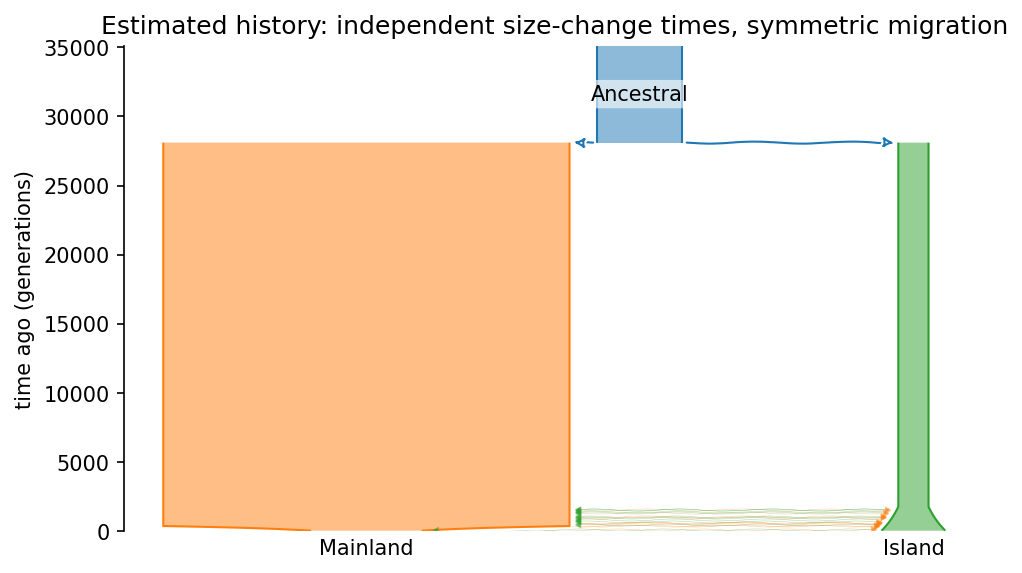

In [19]:
import demes, demesdraw

# ---- mutation/length/gen time (edit as needed)
mu = 8.4e-8
L  = 100_000_000
generation_time = 1.0

# theta, Nref
model_best = func(best_popt, fs.sample_sizes, pts_l)
theta = dadi.Inference.optimal_sfs_scaling(model_best, fs)
Nref  = theta / (4 * mu * L)

(nuM0, nuI0, nuM1, nuI1, T_iso, T_mig, f1, f2, m) = best_popt

# sizes
N_M_iso = nuM0 * Nref
N_I_iso = nuI0 * Nref
N_M_now = nuM1 * Nref
N_I_now = nuI1 * Nref

# absolute times (generations before present)
T_split_gen   = (T_iso + T_mig) * 2 * Nref
T_contact_gen =  T_mig          * 2 * Nref
t1_gen        = (f1 * T_mig)    * 2 * Nref
t2_gen        = (f2 * T_mig)    * 2 * Nref

# per-generation migration (symmetric)
m_per_gen = m / (2 * Nref)

print(f"\nθ={theta:.3f}  Nref={Nref:.1f}")
print(f"Mainland size: isolation={N_M_iso:.1f} → present={N_M_now:.1f}, time={t1_gen:.1f}")
print(f"Island   size: isolation={N_I_iso:.1f} → present={N_I_now:.1f}, time={t2_gen:.1f}")
print(f"Split time: {T_split_gen:.1f} gens, contact start: {T_contact_gen:.1f} gens")
print(f"Symmetric migration m per gen: {m_per_gen:.6g}")

# ---- Demes graph: piecewise with independent size-change times
epsg = 1e-6  # tiny to avoid zero-length epochs
yaml_model = f"""
description: Split→isolation→contact with independent exponential size changes (sym migration)
time_units: generations
generation_time: {generation_time}
demes:
  - name: Ancestral
    start_time: .inf
    epochs:
      - end_time: {max(T_split_gen, epsg):.8f}
        start_size: {max(Nref, epsg):.8f}

  - name: Mainland
    start_time: {max(T_split_gen, epsg):.8f}
    ancestors: [Ancestral]
    epochs:
      - end_time: {max(T_contact_gen, epsg):.8f}
        start_size: {max(N_M_iso, epsg):.8f}
      - end_time: {max(t1_gen, epsg):.8f}
        start_size: {max(N_M_iso, epsg):.8f}
      - end_time: 0
        start_size: {max(N_M_iso, epsg):.8f}
        end_size:   {max(N_M_now, epsg):.8f}
        size_function: exponential

  - name: Island
    start_time: {max(T_split_gen, epsg):.8f}
    ancestors: [Ancestral]
    epochs:
      - end_time: {max(T_contact_gen, epsg):.8f}
        start_size: {max(N_I_iso, epsg):.8f}
      - end_time: {max(t2_gen, epsg):.8f}
        start_size: {max(N_I_iso, epsg):.8f}
      - end_time: 0
        start_size: {max(N_I_iso, epsg):.8f}
        end_size:   {max(N_I_now, epsg):.8f}
        size_function: exponential

migrations:
  - source: Mainland
    dest: Island
    start_time: {max(T_contact_gen, epsg):.8f}
    end_time: 0
    rate: {max(min(m_per_gen, 0.999999), 0.0):.12f}
  - source: Island
    dest: Mainland
    start_time: {max(T_contact_gen, epsg):.8f}
    end_time: 0
    rate: {max(min(m_per_gen, 0.999999), 0.0):.12f}
"""
g = demes.loads(yaml_model)
fig, ax = plt.subplots(1,1, figsize=(7.4,4.2), dpi=150)
demesdraw.tubes(g, ax=ax)
ax.set_title("Estimated history: independent size-change times, symmetric migration")
plt.show()

# # Optional: save YAML/PNG
# import pathlib, demes
# out_dir = pathlib.Path("dadi_fit_indep"); out_dir.mkdir(exist_ok=True, parents=True)
# demes.dump(g, str(out_dir / "modelB.demes.yaml"))
# fig.savefig(out_dir / "modelB.png", dpi=200); plt.close(fig)


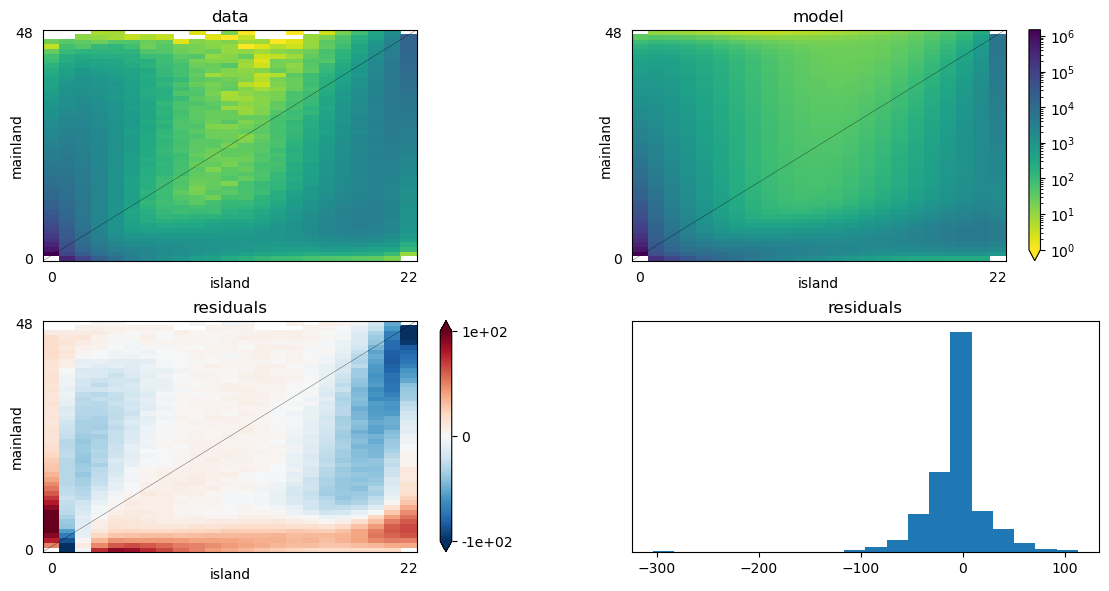

In [20]:
import dadi
import matplotlib.pyplot as plt

# Assuming `fs` is your observed frequency spectrum from the real data
# Assuming `popt` are the optimized parameters from the inferred model

# 1. Generate the model frequency spectrum using the optimized parameters
# Your demographic model function should be already defined (e.g., split_no_mig_model)
model = func(popt, fs.sample_sizes, pts_l)

# 2. Plot the comparison between the observed and model frequency spectrum
fig = plt.figure(figsize=(12, 6))

# Use dadi's plotting function to compare the observed and model FS
dadi.Plotting.plot_2d_comp_multinom(model, fs, vmin=1, resid_range=100)

plt.show()

In [5]:
def split_mig_sym_step_indep(params, ns, pts):
    """
    Params:
      (nuM0, nuI0, nuM1, nuI1,  T_iso, T_mig,  f1, f2,  m)

      nu*_0 : size during isolation and at contact start
      nu*_1 : size after an instantaneous change within contact
      T_iso : duration split→contact (coalescent units)
      T_mig : duration contact→present (coalescent units)
      f1,f2 : fractions in [0,1]; change occurs at t1=f1*T_mig, t2=f2*T_mig before present
      m     : symmetric migration during contact epoch
    """
    import numpy as np
    import dadi

    nuM0, nuI0, nuM1, nuI1, T_iso, T_mig, f1, f2, m = params
    eps = 1e-8
    T_iso = max(T_iso, eps)
    T_mig = max(T_mig, eps)

    # Clamp fractions; convert to "time since contact start" when change happens
    f1 = min(max(f1, 0.0), 1.0)
    f2 = min(max(f2, 0.0), 1.0)
    t1 = f1 * T_mig   # Mainland change happens t1 before present
    t2 = f2 * T_mig   # Island   change happens t2 before present
    startM = T_mig - t1   # time since contact start when Mainland changes
    startI = T_mig - t2

    xx = dadi.Numerics.default_grid(pts)
    deme_ids = ('Mainland', 'Island')

    # CUDA hint so GPU backend keeps the same ordering
    try:
        import dadi.cuda as _dc
        _dc.Integration.deme_ids = deme_ids
    except Exception:
        pass

    # Build phi
    phi = dadi.PhiManip.phi_1D(xx, deme_ids=(deme_ids[0],))
    phi = dadi.PhiManip.phi_1D_to_2D(xx, phi, deme_ids=deme_ids)

    # 1) Isolation: constant sizes, no migration
    phi = dadi.Integration.two_pops(phi, xx, T_iso, nuM0, nuI0, deme_ids=deme_ids)

    # Segment the contact epoch
    smin = max(min(startM, startI), 0.0)
    smax = min(max(startM, startI), T_mig)
    d0 = max(smin, 0.0)          # before any size change: both at *_0
    d1 = max(smax - smin, 0.0)   # only the early-changer has switched to *_1
    d2 = max(T_mig - smax, 0.0)  # both have switched to *_1

    # 2) Contact seg1: both constant at *_0
    if d0 > eps:
        phi = dadi.Integration.two_pops(
            phi, xx, d0, nuM0, nuI0, m12=m, m21=m, deme_ids=deme_ids
        )

    # 3) Contact seg2: whichever changes first flips to *_1 (instantaneous)
    if d1 > eps:
        if startM < startI:
            # Mainland changed; Island still *_0
            phi = dadi.Integration.two_pops(
                phi, xx, d1, nuM1, nuI0, m12=m, m21=m, deme_ids=deme_ids
            )
            curM, curI = nuM1, nuI0
        else:
            # Island changed; Mainland still *_0
            phi = dadi.Integration.two_pops(
                phi, xx, d1, nuM0, nuI1, m12=m, m21=m, deme_ids=deme_ids
            )
            curM, curI = nuM0, nuI1
    else:
        curM, curI = (nuM0, nuI0) if d0 > eps else (nuM1 if startM==0 else nuM0,
                                                    nuI1 if startI==0 else nuI0)

    # 4) Contact seg3: both are at *_1
    if d2 > eps:
        phi = dadi.Integration.two_pops(
            phi, xx, d2, nuM1, nuI1, m12=m, m21=m, deme_ids=deme_ids
        )

    return dadi.Spectrum.from_phi(phi, ns, (xx, xx))  # default mask_corners=True


In [17]:
import numpy as np, matplotlib.pyplot as plt, dadi

# generous grid based on your data fs
nmax = int(np.max(fs.sample_sizes))
pts_l = [nmax + 15, nmax + 25, nmax + 35]

# wrapper to synchronize mask/folding with fs
def model_for_opt(params, ns, pts):
    mfs = split_mig_sym_step_indep(params, ns, pts)
    if fs.folded and not mfs.folded:
        mfs = mfs.fold()
    mfs.mask = fs.mask.copy()
    return mfs

func = dadi.Numerics.make_extrap_log_func(model_for_opt)

# bounds: sizes wide, times reasonable, change fractions in [0,1], symmetric m
lower_bound = [1e-2, 1e-2, 1e-2, 1e-2, 1e-4, 1e-4, 0.0, 0.0, 1e-6]
upper_bound = [1e2,  1e2,  1e2,  1e2,   5.0,  5.0,  1.0-1e-6, 1.0-1e-6, 10.0]

# a reasonable seed (adjust if you like)
p0 = [2.5, 0.5, 3.0, 0.3, 0.6, 0.05, 0.7, 0.4, 3.0]

# optional: warm-up call to compile CUDA kernels
_ = func(p0, fs.sample_sizes, pts_l)

best_ll, best_popt = -np.inf, None
nstarts = 1
for i in range(nstarts):
    pstart = dadi.Misc.perturb_params(
        p0, fold=2.0, lower_bound=lower_bound, upper_bound=upper_bound
    )
    try:
        popt = dadi.Inference.optimize_log(
            pstart, fs, func, pts_l,
            lower_bound=lower_bound, upper_bound=upper_bound,
            verbose=0
        )
        model = func(popt, fs.sample_sizes, pts_l)
        ll = dadi.Inference.ll_multinom(model, fs)
        if ll > best_ll:
            best_ll, best_popt = ll, popt
        print(f"[{i:02d}] ll={ll:.2f}  params={popt}")
    except Exception as e:
        print(f"[{i:02d}] failed: {e}")

print("\nBest log-likelihood:", best_ll)
print("Best params:", best_popt)

[00] ll=-454840.05  params=[2.664789   0.03797474 2.43148166 0.13567692 0.38552263 0.01867114
 0.6006183  0.43925396 9.78732171]

Best log-likelihood: -454840.04829568474
Best params: [2.664789   0.03797474 2.43148166 0.13567692 0.38552263 0.01867114
 0.6006183  0.43925396 9.78732171]


In [14]:
import time, numpy as np, dadi

# ------------------- STEP vs EXP bench wrappers (enable_cuda_cached switch) -------------------
def step_bench(params, ns, pts, use_cuda=True):
    (nuM0, nuI0, nuM1, nuI1, T_iso, T_mig, f1, f2, m) = params
    eps = 1e-8
    T_iso = max(T_iso, eps); T_mig = max(T_mig, eps)
    f1 = min(max(f1, 0.0), 1.0); f2 = min(max(f2, 0.0), 1.0)
    t1 = f1*T_mig; t2 = f2*T_mig
    startM = T_mig - t1; startI = T_mig - t2

    xx = dadi.Numerics.default_grid(pts)
    deme_ids = ('Mainland','Island')
    if use_cuda:
        try:
            import dadi.cuda as _dc; _dc.Integration.deme_ids = deme_ids
        except Exception:
            pass

    phi = dadi.PhiManip.phi_1D(xx, deme_ids=('Mainland',))
    phi = dadi.PhiManip.phi_1D_to_2D(xx, phi, deme_ids=deme_ids)

    phi = dadi.Integration.two_pops(phi, xx, T_iso, nuM0, nuI0,
                                    deme_ids=deme_ids, enable_cuda_cached=use_cuda)

    smin = max(min(startM, startI), 0.0)
    smax = min(max(startM, startI), T_mig)
    d0 = max(smin, 0.0)
    d1 = max(smax - smin, 0.0)
    d2 = max(T_mig - smax, 0.0)

    if d0 > eps:
        phi = dadi.Integration.two_pops(phi, xx, d0, nuM0, nuI0,
                                        m12=m, m21=m, deme_ids=deme_ids,
                                        enable_cuda_cached=use_cuda)
    if d1 > eps:
        if startM < startI:  # Mainland changed first
            phi = dadi.Integration.two_pops(phi, xx, d1, nuM1, nuI0,
                                            m12=m, m21=m, deme_ids=deme_ids,
                                            enable_cuda_cached=use_cuda)
        else:                # Island changed first
            phi = dadi.Integration.two_pops(phi, xx, d1, nuM0, nuI1,
                                            m12=m, m21=m, deme_ids=deme_ids,
                                            enable_cuda_cached=use_cuda)
    if d2 > eps:
        phi = dadi.Integration.two_pops(phi, xx, d2, nuM1, nuI1,
                                        m12=m, m21=m, deme_ids=deme_ids,
                                        enable_cuda_cached=use_cuda)

    return dadi.Spectrum.from_phi(phi, ns, (xx, xx))

def exp_bench(params, ns, pts, use_cuda=True):
    (nuM0, nuI0, nuM1, nuI1, T_iso, T_mig, f1, f2, m) = params
    eps = 1e-8
    T_iso = max(T_iso, eps); T_mig = max(T_mig, eps)
    f1 = min(max(f1, 0.0), 1.0); f2 = min(max(f2, 0.0), 1.0)
    t1 = f1*T_mig; t2 = f2*T_mig
    startM = T_mig - t1; startI = T_mig - t2

    xx = dadi.Numerics.default_grid(pts)
    deme_ids = ('Mainland','Island')
    if use_cuda:
        try:
            import dadi.cuda as _dc; _dc.Integration.deme_ids = deme_ids
        except Exception:
            pass

    phi = dadi.PhiManip.phi_1D(xx, deme_ids=('Mainland',))
    phi = dadi.PhiManip.phi_1D_to_2D(xx, phi, deme_ids=deme_ids)

    phi = dadi.Integration.two_pops(phi, xx, T_iso, nuM0, nuI0,
                                    deme_ids=deme_ids, enable_cuda_cached=use_cuda)

    # segment contact
    smin = max(min(startM, startI), 0.0)
    smax = min(max(startM, startI), T_mig)
    d0 = max(smin, 0.0)
    d1 = max(smax - smin, 0.0)
    d2 = max(T_mig - smax, 0.0)

    def _exp_lambda(s0, s1, total_dur):
        if total_dur <= eps:
            return (lambda t, v=s0: v)
        g = np.log(max(s1, eps) / max(s0, eps))
        if abs(g) < 1e-12:
            return (lambda t, v=s0: v)
        return lambda t, s0=s0, g=g, total_dur=total_dur: s0 * np.exp(g * (t / total_dur))

    if d0 > eps:
        phi = dadi.Integration.two_pops(
            phi, xx, d0, nuM0, nuI0, m12=m, m21=m, deme_ids=deme_ids,
            enable_cuda_cached=use_cuda
        )

    curM, curI = nuM0, nuI0

    if d1 > eps:
        if startM < startI:
            T_remain_M = max(t1, 0.0)
            nuM_seg2 = _exp_lambda(curM, nuM1, max(T_remain_M, eps))
            phi = dadi.Integration.two_pops(
                phi, xx, d1, nu1=nuM_seg2, nu2=(lambda t, v=curI: v),
                m12=m, m21=m, deme_ids=deme_ids,
                enable_cuda_cached=use_cuda
            )
            curM = nuM_seg2(d1)
        else:
            T_remain_I = max(t2, 0.0)
            nuI_seg2 = _exp_lambda(curI, nuI1, max(T_remain_I, eps))
            phi = dadi.Integration.two_pops(
                phi, xx, d1, nu1=(lambda t, v=curM: v), nu2=nuI_seg2,
                m12=m, m21=m, deme_ids=deme_ids,
                enable_cuda_cached=use_cuda
            )
            curI = nuI_seg2(d1)

    if d2 > eps:
        if startM < startI:
            T_left_M = max(t1 - d1, 0.0); T_left_I = max(t2, 0.0)
        else:
            T_left_I = max(t2 - d1, 0.0); T_left_M = max(t1, 0.0)
        nuM_seg3 = _exp_lambda(curM, nuM1, max(T_left_M, eps))
        nuI_seg3 = _exp_lambda(curI, nuI1, max(T_left_I, eps))
        phi = dadi.Integration.two_pops(
            phi, xx, d2, nu1=nuM_seg3, nu2=nuI_seg3,
            m12=m, m21=m, deme_ids=deme_ids,
            enable_cuda_cached=use_cuda
        )

    return dadi.Spectrum.from_phi(phi, ns, (xx, xx))

# ------------------- build extrapolated funcs -------------------
exp_func  = dadi.Numerics.make_extrap_log_func(exp_bench)
step_func = dadi.Numerics.make_extrap_log_func(step_bench)

# ------------------- timing helpers -------------------
def time_model(func, params, ns, pts_l, use_cuda=True, n=10):
    _ = func(params, ns, pts_l, use_cuda=use_cuda)  # warmup
    t0 = time.perf_counter()
    for _ in range(n):
        _ = func(params, ns, pts_l, use_cuda=use_cuda)
    t1 = time.perf_counter()
    return (t1 - t0) / n

def try_gpu(func, *args, **kwargs):
    try:
        return time_model(func, *args, **kwargs, use_cuda=True)
    except Exception:
        return None

# ------------------- pick ns, params, grids -------------------
try:
    ns = tuple(int(x) for x in fs.sample_sizes)
except Exception:
    ns = (48, 22)

params = (2.5, 0.5, 3.0, 0.3, 0.6, 0.05, 0.7, 0.4, 3.0)

grid_sets = [
    [ns[0]+8,  ns[0]+16, ns[0]+24],
    [ns[0]+16, ns[0]+26, ns[0]+36],
    [ns[0]+28, ns[0]+40, ns[0]+52],
]

# ------------------- run sweep -------------------
rows = []
for pts_l in grid_sets:
    t_exp_gpu  = try_gpu(exp_func,  params, ns, pts_l, n=8)
    t_step_gpu = try_gpu(step_func, params, ns, pts_l, n=8)
    t_exp_cpu  = time_model(exp_func,  params, ns, pts_l, use_cuda=False, n=8)
    t_step_cpu = time_model(step_func, params, ns, pts_l, use_cuda=False, n=8)

    rows.append({
        "pts_l": tuple(pts_l),
        "EXP_gpu_ms":  None if t_exp_gpu  is None else 1000*t_exp_gpu,
        "STEP_gpu_ms": None if t_step_gpu is None else 1000*t_step_gpu,
        "EXP_cpu_ms":  1000*t_exp_cpu,
        "STEP_cpu_ms": 1000*t_step_cpu,
    })

# ------------------- print table -------------------
hdr = f"{'pts_l':>18} | {'EXP GPU (ms)':>12} | {'STEP GPU (ms)':>13} | {'EXP CPU (ms)':>12} | {'STEP CPU (ms)':>13}"
print(hdr)
print("-"*len(hdr))
for r in rows:
    def fmt(x):
        return "NA" if x is None else f"{x:>12.2f}"
    print(f"{str(r['pts_l']):>18} | {fmt(r['EXP_gpu_ms'])} | {fmt(r['STEP_gpu_ms'])} | {r['EXP_cpu_ms']:>12.2f} | {r['STEP_cpu_ms']:>13.2f}")

# (optional) speedup summary
if any(r["EXP_gpu_ms"] is not None for r in rows):
    print("\nSpeedup (CPU / GPU):")
    for r in rows:
        if r["EXP_gpu_ms"] is not None and r["STEP_gpu_ms"] is not None:
            s_exp  = r["EXP_cpu_ms"]/r["EXP_gpu_ms"]
            s_step = r["STEP_cpu_ms"]/r["STEP_gpu_ms"]
            print(f"  {r['pts_l']}:  EXP x{s_exp:.2f}   STEP x{s_step:.2f}")


             pts_l | EXP GPU (ms) | STEP GPU (ms) | EXP CPU (ms) | STEP CPU (ms)
--------------------------------------------------------------------------------
      (56, 64, 72) |       231.95 |       163.71 |       458.18 |        458.61
      (64, 74, 84) |       250.06 |       187.43 |       458.63 |        460.32
     (76, 88, 100) |       277.50 |       224.60 |       454.82 |        453.38

Speedup (CPU / GPU):
  (56, 64, 72):  EXP x1.98   STEP x2.80
  (64, 74, 84):  EXP x1.83   STEP x2.46
  (76, 88, 100):  EXP x1.64   STEP x2.02


In [8]:
import time
import numpy as np
import dadi

# --- minimal 2-pop model (split → isolation → contact with symmetric mig) ---
def bench_model(params, ns, pts, use_cuda=True):
    """
    params = (nu1, nu2, T_iso, T_mig, m)
    use_cuda=True  -> allow GPU    (default dadi behavior)
    use_cuda=False -> force CPU    (by disabling the CUDA path)
    """
    (nu1, nu2, T1, T2, m) = params
    xx = dadi.Numerics.default_grid(pts)
    deme_ids = ('P1','P2')

    # CUDA hint (safe no-op if CUDA not installed)
    if use_cuda:
        try:
            import dadi.cuda as _dc
            _dc.Integration.deme_ids = deme_ids
        except Exception:
            pass

    phi = dadi.PhiManip.phi_1D(xx, deme_ids=('P1',))
    phi = dadi.PhiManip.phi_1D_to_2D(xx, phi, deme_ids=deme_ids)

    # isolation (no migration)
    phi = dadi.Integration.two_pops(
        phi, xx, T1, nu1, nu2,
        deme_ids=deme_ids,
        enable_cuda_cached=use_cuda  # key switch
    )
    # contact (symmetric migration)
    phi = dadi.Integration.two_pops(
        phi, xx, T2, nu1, nu2,
        m12=m, m21=m,
        deme_ids=deme_ids,
        enable_cuda_cached=use_cuda  # key switch
    )
    return dadi.Spectrum.from_phi(phi, ns, (xx, xx))

# --- settings (adjust to match your data scale) ---
ns = (48, 22)                # sample sizes
pts_l = [64, 74, 84]         # grid (slightly > ns)
params = (2.0, 0.5, 0.6, 0.05, 3.0)

# extrapolated version to mimic real usage
func = dadi.Numerics.make_extrap_log_func(bench_model)

def time_runs(use_cuda, n=10):
    # warmup (especially important for GPU JIT)
    _ = func(params, ns, pts_l, use_cuda=use_cuda)

    t0 = time.perf_counter()
    for _ in range(n):
        _ = func(params, ns, pts_l, use_cuda=use_cuda)
    t1 = time.perf_counter()
    return (t1 - t0) / n

# --- run benchmark ---
try:
    gpu_ms = time_runs(True, n=10) * 1000
except Exception as e:
    print("GPU run failed (likely no CUDA):", e)
    gpu_ms = None

cpu_ms = time_runs(False, n=10) * 1000

print("\nAvg time per model eval:")
if gpu_ms is not None:
    print(f"  GPU: {gpu_ms:.2f} ms")
else:
    print("  GPU: unavailable")
print(f"  CPU: {cpu_ms:.2f} ms")



Avg time per model eval:
  GPU: 183.29 ms
  CPU: 457.24 ms



θ=723831.638  Nref=21542.6
Mainland: 57406.5 → 52380.5 (step at 483.2 gens)
Island:   818.1 → 2922.8 (step at 353.4 gens)
Split: 17414.8 gens; contact start: 804.5 gens
m per gen (sym): 0.000227162


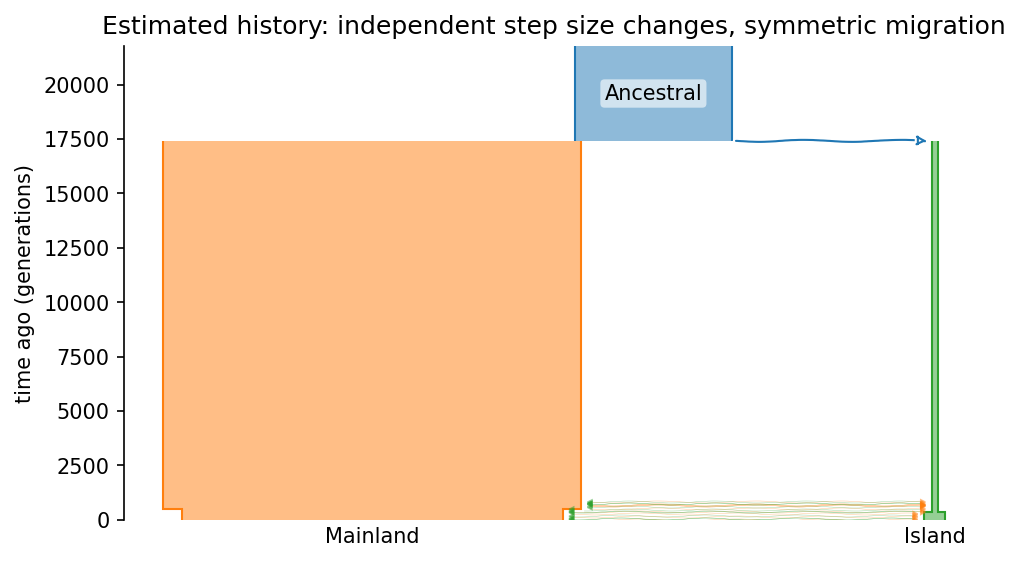

In [18]:
import demes, demesdraw

# edit these:
mu = 8.4e-8
L  = 100_000_000
generation_time = 1.0

model_best = func(best_popt, fs.sample_sizes, pts_l)
theta = dadi.Inference.optimal_sfs_scaling(model_best, fs)
Nref  = theta / (4 * mu * L)

nuM0, nuI0, nuM1, nuI1, T_iso, T_mig, f1, f2, m = best_popt

# sizes
N_M_iso = nuM0 * Nref
N_I_iso = nuI0 * Nref
N_M_now = nuM1 * Nref
N_I_now = nuI1 * Nref

# absolute times (gens before present)
T_split_gen   = (T_iso + T_mig) * 2 * Nref   # split
T_contact_gen =  T_mig          * 2 * Nref   # contact start
t1_gen        = (f1 * T_mig)    * 2 * Nref   # Mainland step time
t2_gen        = (f2 * T_mig)    * 2 * Nref   # Island   step time

# symmetric migration per gen
m_per_gen = m / (2 * Nref)

print(f"\nθ={theta:.3f}  Nref={Nref:.1f}")
print(f"Mainland: {N_M_iso:.1f} → {N_M_now:.1f} (step at {t1_gen:.1f} gens)")
print(f"Island:   {N_I_iso:.1f} → {N_I_now:.1f} (step at {t2_gen:.1f} gens)")
print(f"Split: {T_split_gen:.1f} gens; contact start: {T_contact_gen:.1f} gens")
print(f"m per gen (sym): {m_per_gen:.6g}")

# Demes graph: piecewise-constant with 2 independent step times
epsg = 1e-6
yaml_model = f"""
description: Split→isolation→contact with independent instantaneous size changes (sym migration)
time_units: generations
generation_time: {generation_time}
demes:
  - name: Ancestral
    start_time: .inf
    epochs:
      - end_time: {max(T_split_gen, epsg):.8f}
        start_size: {max(Nref, epsg):.8f}

  - name: Mainland
    start_time: {max(T_split_gen, epsg):.8f}
    ancestors: [Ancestral]
    epochs:
      - end_time: {max(T_contact_gen, epsg):.8f}
        start_size: {max(N_M_iso, epsg):.8f}
      - end_time: {max(t1_gen, epsg):.8f}
        start_size: {max(N_M_iso, epsg):.8f}
      - end_time: 0
        start_size: {max(N_M_now, epsg):.8f}

  - name: Island
    start_time: {max(T_split_gen, epsg):.8f}
    ancestors: [Ancestral]
    epochs:
      - end_time: {max(T_contact_gen, epsg):.8f}
        start_size: {max(N_I_iso, epsg):.8f}
      - end_time: {max(t2_gen, epsg):.8f}
        start_size: {max(N_I_iso, epsg):.8f}
      - end_time: 0
        start_size: {max(N_I_now, epsg):.8f}

migrations:
  - source: Mainland
    dest: Island
    start_time: {max(T_contact_gen, epsg):.8f}
    end_time: 0
    rate: {max(min(m_per_gen, 0.999999), 0.0):.12f}
  - source: Island
    dest: Mainland
    start_time: {max(T_contact_gen, epsg):.8f}
    end_time: 0
    rate: {max(min(m_per_gen, 0.999999), 0.0):.12f}
"""
g = demes.loads(yaml_model)
fig, ax = plt.subplots(1,1, figsize=(7.4,4.1), dpi=150)
demesdraw.tubes(g, ax=ax)
ax.set_title("Estimated history: independent step size changes, symmetric migration")
plt.show()

# # Optional: save
# import pathlib
# out_dir = pathlib.Path("dadi_fit_step"); out_dir.mkdir(exist_ok=True, parents=True)
# demes.dump(g, str(out_dir / "model_step.demes.yaml"))
# fig.savefig(out_dir / "model_step.png", dpi=200); plt.close(fig)


In [ ]:
import dadi
import matplotlib.pyplot as plt

# Assuming `fs` is your observed frequency spectrum from the real data
# Assuming `popt` are the optimized parameters from the inferred model

# 1. Generate the model frequency spectrum using the optimized parameters
# Your demographic model function should be already defined (e.g., split_no_mig_model)
model = func(popt, fs.sample_sizes, pts_l)

# 2. Plot the comparison between the observed and model frequency spectrum
fig = plt.figure(figsize=(12, 6))

# Use dadi's plotting function to compare the observed and model FS
dadi.Plotting.plot_2d_comp_multinom(model, fs, vmin=1, resid_range=100)

plt.show()

In [12]:
# ============================================================
# SIMPLE 1D (mainland & island) multi-epoch fits with AIC
# - Models: k = 2, 3, 4 epochs, piecewise-constant sizes
# - Prints log-likelihood for EVERY random start
# - Prints AIC table, Akaike weights, and interpretable params
# - SAVE NOTHING
# Requirements in current session: fs (2D dadi.Spectrum), mu, L, generation_time
# ============================================================

import numpy as np
import math
import dadi
dadi.cuda_enabled(True)

# ---- sanity checks / defaults (uses your existing values when present) ----
try:
    fs
except NameError:
    raise RuntimeError("This cell expects a 2D dadi.Spectrum named `fs` to already exist.")
try:
    mu
except NameError:
    mu = 8.4e-8
try:
    L
except NameError:
    L = 100_000_000
try:
    generation_time
except NameError:
    generation_time = 1

# ---- config you can tweak quickly ----
PTS_L = [50, 60, 70]     # extrapolation grid
SIZE_BOUNDS = (1e-3, 1e2)  # bounds for nu (relative to Na)
TIME_BOUNDS = (1e-4, 5.0)  # bounds for epoch durations (in 2*Na units)
N_STARTS = 10
SEED = 42

rng = np.random.default_rng(SEED)

# Helper: marginalize to 1D (keep_axis=0 for mainland, 1 for island)
def _marginal_1d(fs2d, keep_axis):
    if keep_axis == 0:
        return fs2d.marginalize([1])
    elif keep_axis == 1:
        return fs2d.marginalize([0])
    else:
        raise ValueError("keep_axis must be 0 or 1")

# Helper: log-uniform draws
def _rand_log_uniform(low, high, size):
    lo, hi = math.log10(low), math.log10(high)
    return (10 ** rng.uniform(lo, hi, size=size)).astype(float)

# Run for each population in turn
for pop_name, keep_axis in [("mainland", 0), ("island", 1)]:
    print("\n" + "="*72)
    print(f"{pop_name.upper()} (axis {keep_axis}) 1D marginal SFS")
    fs1d = _marginal_1d(fs, keep_axis)
    print(fs1d)

    model_summaries = {}   # k -> dict with ll, aic, params, theta, Na, etc.

    # Fit k-epoch models
    for k in (2, 3, 4):
        print(f"\n--- Fitting {k}-epoch model for {pop_name} ---")

        # Inline model definition for this k (piecewise-constant sizes, oldest -> present)
        def _model_k(params, ns, pts):
            nus = params[:k]
            Ts  = params[k:]
            xx = dadi.Numerics.default_grid(pts)
            phi = dadi.PhiManip.phi_1D(xx)
            for i in range(k):  # integrate oldest -> present
                phi = dadi.Integration.one_pop(phi, xx, Ts[i], nus[i])
            return dadi.Spectrum.from_phi(phi, ns, (xx,), mask_corners=False)

        func = dadi.Numerics.make_extrap_log_func(_model_k)
        ns_1d = fs1d.sample_sizes

        lower = [SIZE_BOUNDS[0]] * k + [TIME_BOUNDS[0]] * k
        upper = [SIZE_BOUNDS[1]] * k + [TIME_BOUNDS[1]] * k

        best_ll = -np.inf
        best_popt = None
        n_fail = 0

        # Try N_STARTS random initializations; PRINT each try's log-likelihood
        for s in range(N_STARTS):
            p0_sizes = _rand_log_uniform(SIZE_BOUNDS[0], SIZE_BOUNDS[1], size=k)
            p0_times = _rand_log_uniform(TIME_BOUNDS[0], TIME_BOUNDS[1], size=k)
            p0 = np.concatenate([p0_sizes, p0_times])

            try:
                popt = dadi.Inference.optimize_log(
                    p0, fs1d, func, PTS_L,
                    lower_bound=lower, upper_bound=upper,
                    verbose=False
                )
                model = func(popt, ns_1d, PTS_L)
                ll = dadi.Inference.ll_multinom(model, fs1d)
                print(f"  start {s+1:02d}/{N_STARTS}: logL={ll:.3f}")
                if ll > best_ll:
                    best_ll = ll
                    best_popt = popt
            except Exception as e:
                n_fail += 1
                print(f"  start {s+1:02d}/{N_STARTS}: FAILED ({type(e).__name__})")

        if best_popt is None:
            raise RuntimeError(f"All starts failed for {pop_name} k={k} (failures={n_fail}).")

        # Summaries for AIC and interpretation
        k_params = 2 * k
        aic = 2 * k_params - 2 * best_ll

        # Interpretable scaling
        best_model = func(best_popt, ns_1d, PTS_L)
        theta = dadi.Inference.optimal_sfs_scaling(best_model, fs1d)
        Na = theta / (4.0 * mu * L)

        # Epoch sizes & times
        nus = np.array(best_popt[:k], dtype=float)
        Ts  = np.array(best_popt[k:], dtype=float)

        Ne_epochs = nus * Na                                  # ancient -> present
        epoch_durations_gen = Ts * (2.0 * Na)                 # per-epoch duration, gens
        # boundaries older->recent: time BP where size changes
        change_times_gen = [float(np.sum(epoch_durations_gen[i+1:])) for i in range(k-1)]
        change_times_years = [g * generation_time for g in change_times_gen]

        print(f"\n  Best {k}-epoch for {pop_name}:")
        print(f"    logL = {best_ll:.3f}")
        print(f"    AIC  = {aic:.3f}   (k_params = {k_params})")
        print(f"    theta = {theta:.6g}   Na ≈ {Na:,.2f}")
        for i in range(k):
            tag = " (present)" if i == k-1 else ""
            print(f"    Epoch {i+1}: nu={nus[i]:.5g}  → Ne≈{Ne_epochs[i]:,.1f}{tag} "
                  f"| duration≈{epoch_durations_gen[i]:,.1f} gens")
        for j, (g, y) in enumerate(zip(change_times_gen, change_times_years), start=1):
            print(f"    Change {j}: ~{g:,.1f} generations (~{y:,.1f} years) BP")

        model_summaries[k] = dict(
            best_ll=float(best_ll),
            aic=float(aic),
            k_params=k_params,
            theta=float(theta),
            Na=float(Na),
            nus=nus.tolist(),
            Ts=Ts.tolist(),
            Ne_epochs=Ne_epochs.tolist(),
            epoch_durations_gen=[float(x) for x in epoch_durations_gen],
            change_times_gen=change_times_gen,
            change_times_years=change_times_years,
        )

    # ---- AIC table + weights for this population ----
    print(f"\nAIC summary for {pop_name} (lower is better):")
    ks = [2, 3, 4]
    aics = np.array([model_summaries[k]['aic'] for k in ks], dtype=float)
    deltas = aics - np.min(aics)
    weights = np.exp(-0.5 * deltas)
    weights /= np.sum(weights)
    for k, dAIC, w in zip(ks, deltas, weights):
        r = model_summaries[k]
        print(f"  k={k}: AIC={r['aic']:.3f} | ΔAIC={dAIC:.3f} | weight={w:.3f} | logL={r['best_ll']:.3f}")

    # ---- Print best model interpretable summary again (clean) ----
    best_k = ks[int(np.argmin(aics))]
    best = model_summaries[best_k]
    print(f"\nBEST for {pop_name}: {best_k}-epoch")
    print(f"  theta={best['theta']:.6g}  Na≈{best['Na']:,.1f}  Ne(present)≈{best['Ne_epochs'][-1]:,.1f}")
    for i in range(best_k):
        tag = " (present)" if i == best_k-1 else ""
        print(f"  Epoch {i+1}: nu={best['nus'][i]:.6g}  → Ne≈{best['Ne_epochs'][i]:,.1f}{tag} "
              f"| duration≈{best['epoch_durations_gen'][i]:,.1f} gens")
    for j, (g, y) in enumerate(zip(best['change_times_gen'], best['change_times_years']), start=1):
        print(f"  Change {j}: ~{g:,.1f} generations (~{y:,.1f} years) BP")




MAINLAND (axis 0) 1D marginal SFS
[-- 1572572.0 715904.0 413358.0 268646.0 188404.0 141769.0 111732.0
 92163.0 77785.0 67396.0 58428.0 52276.0 47086.0 43165.0 40189.0 37903.0
 35607.0 33999.0 32179.0 31360.0 30260.0 29560.0 29012.0 28170.0 27431.0
 26873.0 26023.0 25632.0 25125.0 25094.0 24021.0 24392.0 24275.0 23566.0
 23057.0 23354.0 22922.0 22874.0 22328.0 22473.0 21314.0 21116.0 20397.0
 20737.0 20148.0 20236.0 20038.0 --]

--- Fitting 2-epoch model for mainland ---
  start 01/10: logL=-294362.666
  start 02/10: logL=-186093.078
  start 03/10: logL=-290705.494
  start 04/10: logL=-119889.247
  start 05/10: logL=-290705.494
  start 06/10: logL=-290705.494
  start 07/10: logL=-29749.188
  start 08/10: logL=-179017.018
  start 09/10: logL=-562814.072
  start 10/10: logL=-31983.026

  Best 2-epoch for mainland:
    logL = -29749.188
    AIC  = 59506.376   (k_params = 4)
    theta = 795373   Na ≈ 23,671.81
    Epoch 1: nu=4.1656  → Ne≈98,607.2 | duration≈6,829.8 gens
    Epoch 2: nu=0.

  start 10/10: logL=-290705.494

  Best 4-epoch for mainland:
    logL = -11741.500
    AIC  = 23499.001   (k_params = 8)
    theta = 705109   Na ≈ 20,985.39
    Epoch 1: nu=0.0015039  → Ne≈31.6 | duration≈10.1 gens
    Epoch 2: nu=4.2929  → Ne≈90,087.2 | duration≈16,317.0 gens
    Epoch 3: nu=0.4044  → Ne≈8,486.5 | duration≈250.8 gens
    Epoch 4: nu=94.25  → Ne≈1,977,876.8 (present) | duration≈17.0 gens
    Change 1: ~16,584.9 generations (~16,584.9 years) BP
    Change 2: ~267.9 generations (~267.9 years) BP
    Change 3: ~17.0 generations (~17.0 years) BP

AIC summary for mainland (lower is better):
  k=2: AIC=59506.376 | ΔAIC=50490.062 | weight=0.000 | logL=-29749.188
  k=3: AIC=9016.314 | ΔAIC=0.000 | weight=1.000 | logL=-4502.157
  k=4: AIC=23499.001 | ΔAIC=14482.687 | weight=0.000 | logL=-11741.500

BEST for mainland: 3-epoch
  theta=2.00729e+08  Na≈5,974,072.8  Ne(present)≈51,415.6
  Epoch 1: nu=0.00645566  → Ne≈38,566.6 | duration≈564,211.7 gens
  Epoch 2: nu=0.00102699  → Ne

In [35]:
# ================= HIERARCHICAL, CONSTRAINED FIT (improved sampling) =================
# Key updates:
#  - Log-space time sampling + Latin hypercube
#  - Tighter caps (adjacent-size ratio, min durations incl. recent epoch)
#  - Seed de-duplication
#  - Penalized global ranking (smoothness + min-duration), AIC on true logL
#  - No forced monotonicity of sizes

import numpy as np, math, dadi

# ---- expects fs (2D), mu, L, generation_time in memory ----
try: fs
except NameError: raise RuntimeError("Need 2D SFS `fs` in memory.")
mu = globals().get("mu", 8.4e-8)
L  = globals().get("L",  100_000_000)
generation_time = globals().get("generation_time", 1)

rng = np.random.default_rng(202503)  # new seed

# ------------------- knobs -------------------
PTS_GLOBAL = [40, 50, 60]
PTS_LOCAL  = [50, 60, 70]

# Time windows (gens) — tune per population if you like
WINDOW_T_MIN = 1_000
WINDOW_T_MAX = 150_000

MIN_EPOCH_DUR       = 1_000   # min duration each epoch
MIN_RECENT_DURATION = 500     # min duration for the most-recent epoch
MAX_ADJ_RATIO       = 25.0    # cap on adjacent size jumps

NU_MIN, NU_MAX = 0.1, 10.0    # sizes relative to Na

N_GLOBAL_SAMPLES = 12000       # like your latest run
TOP_M            = 400         # shortlist per k (smaller than 60 to cut redundancy)

# Penalty weights for global ranking only (not used for final AIC)
LAMBDA_ROUGH   = 1.0          # penalty on sum (Δlog nu)^2
GAMMA_DUR_SOFT = 1e-3         # penalty per (shortfall gens); tune 1e-4–1e-2

# ---------------- utils ----------------
def _grid(pts):
    if isinstance(pts, (list, tuple, np.ndarray)):
        return dadi.Numerics.default_grid(int(np.max(pts)))
    return dadi.Numerics.default_grid(int(pts))

def marginal_1d(fs2d, keep_axis):
    return fs2d.marginalize([1]) if keep_axis==0 else fs2d.marginalize([0])

def Na_ref_const(fs1d):
    xx = _grid(PTS_GLOBAL)
    phi = dadi.PhiManip.phi_1D(xx)
    model = dadi.Spectrum.from_phi(phi, fs1d.sample_sizes, (xx,), mask_corners=False)
    theta = dadi.Inference.optimal_sfs_scaling(model, fs1d)
    return theta/(4.0*mu*L), theta

def violates_ratio(nus, cap=MAX_ADJ_RATIO):
    for a,b in zip(nus[:-1], nus[1:]):
        if a<=0 or b<=0: return True
        if abs(math.log(b/a)) > math.log(cap):
            return True
    return False

def durations_from_cuts_anc_to_cur(cuts):
    # cuts are generations BP, sorted ascending (recent -> older)
    cuts = np.sort(np.asarray(cuts, float))
    seg_present_to_anc = [cuts[0]] + [cuts[i]-cuts[i-1] for i in range(1, len(cuts))]
    return list(reversed(seg_present_to_anc))  # ancient -> present durations

def model_from_nus_cuts(fs1d, nus, cuts_gens, Na_for_T, pts):
    d_anc_to_cur = durations_from_cuts_anc_to_cur(cuts_gens)
    # hard duration constraints
    if any(d < MIN_EPOCH_DUR for d in d_anc_to_cur):
        return None
    if d_anc_to_cur[-1] < MIN_RECENT_DURATION:
        return None
    Ts = [d/(2.0*Na_for_T) for d in d_anc_to_cur]
    xx = _grid(pts)
    phi = dadi.PhiManip.phi_1D(xx)
    for nu, T in zip(nus, Ts):
        phi = dadi.Integration.one_pop(phi, xx, T, nu)
    return dadi.Spectrum.from_phi(phi, fs1d.sample_sizes, (xx,), mask_corners=False)

def roughness(nus):
    ln = np.log(np.asarray(nus, float))
    if len(ln) <= 1: return 0.0
    dif = np.diff(ln)
    return float(np.sum(dif**2))

def soft_duration_shortfall(cuts):
    d = durations_from_cuts_anc_to_cur(cuts)
    short = sum(max(0.0, MIN_EPOCH_DUR - x) for x in d)
    short += max(0.0, MIN_RECENT_DURATION - d[-1])
    return float(short)

def log_uniform_times(k_minus_1, low=WINDOW_T_MIN, high=WINDOW_T_MAX):
    lo, hi = np.log(low), np.log(high)
    return np.sort(np.exp(rng.uniform(lo, hi, size=k_minus_1)))

def latin_hypercube(n, d):
    # simple LHS in [0,1]; shape (n, d)
    P = np.zeros((n, d))
    cut = np.linspace(0, 1, n+1)
    for j in range(d):
        u = rng.uniform(cut[:-1], cut[1:])
        rng.shuffle(u)
        P[:, j] = u
    return P

def sample_global_candidates(k, n=N_GLOBAL_SAMPLES):
    # LHS for sizes in [NU_MIN, NU_MAX] (linear scale)
    lhs_sizes = latin_hypercube(n, k)
    sizes = NU_MIN + (NU_MAX-NU_MIN)*lhs_sizes
    # times in log-space: use LHS on [log Tmin, log Tmax]
    lhs_times = latin_hypercube(n, k-1)
    cuts = np.exp(np.log(WINDOW_T_MIN) + (np.log(WINDOW_T_MAX)-np.log(WINDOW_T_MIN))*lhs_times)
    cuts.sort(axis=1)
    return sizes, cuts

def dedup_seeds(seed_list, tol_log_nu=0.15, tol_time_frac=0.08):
    # remove near-duplicates: closeness in log size & relative cut positions
    kept = []
    for ll, nus, cuts in seed_list:
        ln = np.log(nus)
        rel = cuts / cuts[-1]
        is_dup = False
        for _, n2, c2 in kept:
            if np.linalg.norm(ln - np.log(n2)) < tol_log_nu and np.linalg.norm(rel - (c2/c2[-1])) < tol_time_frac:
                is_dup = True; break
        if not is_dup:
            kept.append((ll, nus, cuts))
        if len(kept) >= TOP_M:
            break
    return kept

# ---------------- global scan ----------------
def global_scan(fs1d, k, Na_ref):
    sizes, cuts = sample_global_candidates(k, N_GLOBAL_SAMPLES)
    scored = []
    for i in range(N_GLOBAL_SAMPLES):
        nus  = sizes[i]
        if violates_ratio(nus):  # size jump guard
            continue
        cts  = cuts[i]
        m = model_from_nus_cuts(fs1d, nus, cts, Na_ref, PTS_GLOBAL)
        if m is None:
            continue
        ll = dadi.Inference.ll_multinom(m, fs1d)
        # penalized score (for ranking only)
        score = ll - LAMBDA_ROUGH*roughness(nus) - GAMMA_DUR_SOFT*soft_duration_shortfall(cts)
        scored.append((score, ll, nus.copy(), cts.copy()))
    scored.sort(key=lambda x: x[0], reverse=True)
    # keep top by penalized score, but return true ll for AIC later
    seeds = [(ll, nus, cts) for _, ll, nus, cts in scored[:TOP_M*4]]  # take more, then dedup
    seeds = dedup_seeds(seeds, tol_log_nu=0.15, tol_time_frac=0.08)
    return seeds

# ---------------- local jitter refine (cheap) ----------------
def local_refine(fs1d, k, Na_ref, seed):
    best_ll, best_p = -np.inf, None
    seed_ll, seed_nus, seed_cuts = seed
    lo_nu = np.maximum(NU_MIN,  seed_nus/2.5)
    hi_nu = np.minimum(NU_MAX,  seed_nus*2.5)
    for j in range(30):  # a few more jitters since it's cheap
        # independent jitter; no sorting (allow up/down)
        nus = rng.uniform(lo_nu, hi_nu, size=k)
        if violates_ratio(nus): 
            continue
        # ~±15% log-normal jitter on cuts
        jitter = np.exp(rng.normal(0, 0.15, size=k-1))
        cuts   = np.clip(seed_cuts * jitter, WINDOW_T_MIN, WINDOW_T_MAX)
        cuts   = np.sort(cuts)
        m = model_from_nus_cuts(fs1d, nus, cuts, Na_ref, PTS_LOCAL)
        if m is None:
            continue
        ll = dadi.Inference.ll_multinom(m, fs1d)
        if ll > best_ll:
            best_ll, best_p = ll, (nus.copy(), cuts.copy())
    return best_ll, best_p

# ---------------- driver ----------------
def run_pop(fs2d, pop_name, axis, ks=(2,3,4)):
    print("\n" + "="*76)
    print(f"{pop_name.upper()} (axis {axis})")
    fs1d = marginal_1d(fs2d, axis)
    print(fs1d)

    Na_ref, theta_ref = Na_ref_const(fs1d)
    print(f"Ref: theta≈{theta_ref:.3g}, Na_ref≈{Na_ref:,.0f}")

    results = {}
    for k in ks:
        seeds = global_scan(fs1d, k, Na_ref)
        if not seeds:
            print(f"  k={k}: no valid seeds under constraints")
            continue
        best_ll, best = -np.inf, None
        for sd in seeds:
            ll, p = local_refine(fs1d, k, Na_ref, sd)
            if p is not None and ll > best_ll:
                best_ll, best = ll, p
        if best is None:
            print(f"  k={k}: local refine failed")
            continue

        nus, cuts = best
        model = model_from_nus_cuts(fs1d, nus, cuts, Na_ref, PTS_LOCAL)
        theta = dadi.Inference.optimal_sfs_scaling(model, fs1d)
        Na    = theta/(4.0*mu*L)

        d_anc_to_cur = durations_from_cuts_anc_to_cur(cuts)
        Ne_epochs = (nus*Na).tolist()

        k_params = 2*k
        aic = 2*k_params - 2*best_ll

        print(f"\n  >>> Best k={k} for {pop_name}:")
        print(f"      logL={best_ll:.3f} | AIC={aic:.3f} | theta={theta:.3g} | Na≈{Na:,.1f}")
        for i,(nu,Ne,dur) in enumerate(zip(nus, Ne_epochs, d_anc_to_cur),1):
            tag=" (present)" if i==k else ""
            print(f"      Epoch {i}: nu={nu:.4g} → Ne≈{Ne:,.0f}{tag} | duration≈{dur:,.0f} gens")
        for j in range(k-1):
            print(f"      Change {j+1}: ~{sum(d_anc_to_cur[j+1:]):,.0f} gens BP")

        results[k] = dict(aic=aic, ll=best_ll, nus=nus, cuts=cuts, Na=Na, theta=theta)

    if results:
        print(f"\nAIC summary for {pop_name}:")
        ks_list = sorted(results.keys())
        aics = np.array([results[k]['aic'] for k in ks_list])
        deltas = aics - aics.min()
        w = np.exp(-0.5*deltas); w/=w.sum()
        for k, d in zip(ks_list, deltas):
            r = results[k]
            print(f"  k={k}: AIC={r['aic']:.1f} | ΔAIC={d:.1f} | weight={float(w[list(ks_list).index(k)]):.3f} | logL={r['ll']:.1f}")

# ---------------- run both pops ----------------
run_pop(fs, "mainland", 0, ks=(2,3,4))
run_pop(fs, "island",   1, ks=(2,3,4))



MAINLAND (axis 0)
[-- 655298.0 306034.0 186102.0 131579.0 100109.0 80745.0 67745.0 58613.0
 51234.0 46170.0 42113.0 39034.0 35490.0 33464.0 30687.0 29530.0 27851.0
 25773.0 25275.0 23556.0 22572.0 22263.0 21055.0 20017.0 19472.0 19164.0
 18143.0 17523.0 17148.0 16635.0 16268.0 15785.0 15434.0 15171.0 14525.0
 14106.0 13842.0 13652.0 12963.0 12710.0 12364.0 12058.0 11759.0 11100.0
 11357.0 11562.0 11185.0 --]
Ref: theta≈5.4e+05, Na_ref≈16,069

  >>> Best k=2 for mainland:
      logL=-1424.863 | AIC=2857.727 | theta=4.79e+05 | Na≈14,255.4
      Epoch 1: nu=1.6 → Ne≈22,807 | duration≈3,437 gens
      Change 1: ~0 gens BP

  >>> Best k=3 for mainland:
      logL=-584.791 | AIC=1181.582 | theta=6.07e+05 | Na≈18,058.9
      Epoch 1: nu=0.732 → Ne≈13,219 | duration≈39,263 gens
      Epoch 2: nu=1.209 → Ne≈21,837 | duration≈3,761 gens
      Change 1: ~3,761 gens BP
      Change 2: ~0 gens BP



  >>> Best k=4 for mainland:
      logL=-635.199 | AIC=1286.398 | theta=5.25e+05 | Na≈15,612.6
      Epoch 1: nu=0.6787 → Ne≈10,596 | duration≈12,384 gens
      Epoch 2: nu=8.796 → Ne≈137,324 | duration≈1,731 gens
      Epoch 3: nu=1.287 → Ne≈20,098 | duration≈3,729 gens
      Change 1: ~5,460 gens BP
      Change 2: ~3,729 gens BP
      Change 3: ~0 gens BP

AIC summary for mainland:
  k=2: AIC=2857.7 | ΔAIC=1676.1 | weight=0.000 | logL=-1424.9
  k=3: AIC=1181.6 | ΔAIC=0.0 | weight=1.000 | logL=-584.8
  k=4: AIC=1286.4 | ΔAIC=104.8 | weight=0.000 | logL=-635.2

ISLAND (axis 1)
[-- 816845.0 269997.0 154595.0 111886.0 91120.0 77382.0 67485.0 59423.0
 52841.0 48463.0 44692.0 41534.0 38164.0 36349.0 34151.0 32262.0 30321.0
 28013.0 26520.0 25155.0 24029.0 --]
Ref: theta≈5.75e+05, Na_ref≈17,104

  >>> Best k=2 for island:
      logL=-1437.228 | AIC=2882.456 | theta=4.75e+05 | Na≈14,148.0
      Epoch 1: nu=6.225 → Ne≈88,076 | duration≈3,068 gens
      Change 1: ~0 gens BP

  >>> Best k=3 f

In [36]:
# ======= Hierarchical scan (deep), correct durations, and short optimizer polish =======
# Drop this in place of the previous driver. Prints results; saves nothing.

import numpy as np, math, dadi

# expects fs (2D), mu, L, generation_time in memory
try: fs
except NameError: raise RuntimeError("Need 2D SFS `fs` in memory.")
mu = globals().get("mu", 8.4e-8)
L  = globals().get("L",  100_000_000)
generation_time = globals().get("generation_time", 1)

rng = np.random.default_rng(202506)

# ---------------- knobs ----------------
PTS_GLOBAL = [40, 50, 60]
PTS_LOCAL  = [50, 60, 70]

# Analysis window in generations BP (guided by RELATE)
WINDOW_T_MIN   = 1_000
WINDOW_T_MAX   = 150_000
T_MAX_INFER    = WINDOW_T_MAX   # anchor the ancient boundary here

# Plausibility constraints
MIN_EPOCH_DUR       = 1_000    # each epoch >= 1k gens
MIN_RECENT_DURATION = 500      # present epoch >= 500 gens
MAX_ADJ_RATIO       = 30.0     # adjacent size jump cap (10–20 is sensible)
NU_MIN, NU_MAX      = 0.1, 10.0

# Global search depth (heavier than the quick pass that regressed)
GLOBAL_PER_BATCH = 10000        # candidates per batch per k
NUM_BATCHES      = 6           # total candidates per k ≈ 12k
# (No early-stop; we want depth again.)

# Local jitter tries per shortlisted seed
LOCAL_JITTER_TRIES = 48

# Optimizer polish on top seeds (fast but finds the basin edge)
DO_POLISH      = True
POLISH_TOP     = 4
POLISH_MAXITER = 200

# ---------------- helpers ----------------
def _grid(pts):
    if isinstance(pts, (list, tuple, np.ndarray)):
        return dadi.Numerics.default_grid(int(np.max(pts)))
    return dadi.Numerics.default_grid(int(pts))

def marginal_1d(fs2d, keep_axis):
    return fs2d.marginalize([1]) if keep_axis==0 else fs2d.marginalize([0])

def Na_ref_const(fs1d):
    xx = _grid(PTS_GLOBAL)
    phi = dadi.PhiManip.phi_1D(xx)
    model = dadi.Spectrum.from_phi(phi, fs1d.sample_sizes, (xx,), mask_corners=False)
    theta = dadi.Inference.optimal_sfs_scaling(model, fs1d)
    return theta/(4.0*mu*L), theta

def violates_ratio(nus, cap=MAX_ADJ_RATIO):
    for a,b in zip(nus[:-1], nus[1:]):
        if a<=0 or b<=0: return True
        if abs(math.log(b/a)) > math.log(cap): return True
    return False

def durations_from_cuts_k_epochs(cuts, t_max=T_MAX_INFER):
    """
    cuts: (k-1) change times in gens BP, strictly increasing (recent -> older).
    Returns k durations (ancient -> present) that fill [0, t_max]:
      [t_max - t_{k-1}, (t_{k-1}-t_{k-2}), ..., (t2 - t1), (t1 - 0)]
    """
    c = np.sort(np.asarray(cuts, float))
    d = [t_max - c[-1]] + [c[i] - c[i-1] for i in range(len(c)-1, 0, -1)] + [c[0] - 0.0]
    # order is ancient->present already
    return d

def model_from_nus_cuts(fs1d, nus, cuts_gens, Na_for_T, pts):
    d = durations_from_cuts_k_epochs(cuts_gens, T_MAX_INFER)   # k durations
    # hard duration constraints
    if any(x < MIN_EPOCH_DUR for x in d): return None
    if d[-1] < MIN_RECENT_DURATION: return None
    Ts = [x/(2.0*Na_for_T) for x in d]
    xx = _grid(pts)
    phi = dadi.PhiManip.phi_1D(xx)
    for nu, T in zip(nus, Ts):
        phi = dadi.Integration.one_pop(phi, xx, T, nu)
    return dadi.Spectrum.from_phi(phi, fs1d.sample_sizes, (xx,), mask_corners=False)

def latin_hypercube(n, d):
    P = np.zeros((n, d))
    cut = np.linspace(0, 1, n+1)
    for j in range(d):
        u = rng.uniform(cut[:-1], cut[1:])
        rng.shuffle(u)
        P[:, j] = u
    return P

def sample_global(k, n):
    # sizes: LHS linear in [NU_MIN, NU_MAX]
    lhs_s = latin_hypercube(n, k)
    sizes = NU_MIN + (NU_MAX-NU_MIN)*lhs_s
    # times: LHS log in [Tmin, Tmax - MIN_EPOCH_DUR] to keep ancient duration >= min
    lhs_t = latin_hypercube(n, k-1)
    lo, hi = np.log(WINDOW_T_MIN), np.log(WINDOW_T_MAX - MIN_EPOCH_DUR)
    raw = np.exp(lo + (hi-lo)*lhs_t)
    raw.sort(axis=1)
    # reject if last cut violates ancient min duration
    ok = raw[:,-1] <= (T_MAX_INFER - MIN_EPOCH_DUR)
    return sizes[ok], raw[ok]

def dedup(seeds, keep=16, tol_log_nu=0.12, tol_time_frac=0.06):
    out = []
    for ll, nus, cuts in seeds:
        ln, rel = np.log(nus), cuts/cuts[-1]
        dup = False
        for _, n2, c2 in out:
            if np.linalg.norm(ln-np.log(n2)) < tol_log_nu and np.linalg.norm(rel-(c2/c2[-1])) < tol_time_frac:
                dup = True; break
        if not dup:
            out.append((ll, nus, cuts))
        if len(out) >= keep: break
    return out

def local_jitter(fs1d, k, Na_ref, seed):
    best_ll, best = -np.inf, None
    sll, snus, scuts = seed
    lo = np.maximum(NU_MIN, snus/2.0)
    hi = np.minimum(NU_MAX, snus*2.0)
    for _ in range(LOCAL_JITTER_TRIES):
        nus  = rng.uniform(lo, hi, size=k)
        if violates_ratio(nus): continue
        # jitter cuts in log-space ≈ ±15%
        cuts = np.sort(np.clip(scuts*np.exp(rng.normal(0,0.15,size=k-1)), WINDOW_T_MIN, T_MAX_INFER - MIN_EPOCH_DUR))
        if cuts[-1] > (T_MAX_INFER - MIN_EPOCH_DUR): continue
        m = model_from_nus_cuts(fs1d, nus, cuts, Na_ref, PTS_LOCAL)
        if m is None: continue
        ll = dadi.Inference.ll_multinom(m, fs1d)
        if ll > best_ll:
            best_ll, best = ll, (nus.copy(), cuts.copy())
    return best_ll, best

def polish_opt(fs1d, k, Na_ref, nus, cuts):
    d = durations_from_cuts_k_epochs(cuts, T_MAX_INFER)
    Ts = [x/(2.0*Na_ref) for x in d]
    T_lo = MIN_EPOCH_DUR/(2.0*Na_ref)
    T_hi = T_MAX_INFER /(2.0*Na_ref)
    lower = [NU_MIN]*k + [T_lo]*k
    upper = [NU_MAX]*k + [T_hi]*k
    ns = fs1d.sample_sizes

    def model_k(params, ns, pts):
        nus_, Ts_ = params[:k], params[k:]
        xx = dadi.Numerics.default_grid(pts)
        phi = dadi.PhiManip.phi_1D(xx)
        for i in range(k):
            phi = dadi.Integration.one_pop(phi, xx, Ts_[i], nus_[i])
        return dadi.Spectrum.from_phi(phi, ns, (xx,), mask_corners=False)

    func = dadi.Numerics.make_extrap_log_func(model_k)
    p0 = np.concatenate([nus, Ts])
    try:
        popt = dadi.Inference.optimize_log(
            p0, fs1d, func, PTS_LOCAL,
            lower_bound=lower, upper_bound=upper, maxiter=POLISH_MAXITER, verbose=False
        )
        model = func(popt, ns, PTS_LOCAL)
        ll = dadi.Inference.ll_multinom(model, fs1d)
        return ll, popt[:k], popt[k:]
    except Exception:
        return -np.inf, nus, np.array(Ts)

# ---------------- main driver ----------------
def run_pop_deep(fs2d, pop_name, axis, ks=(2,3,4)):
    print("\n" + "="*76)
    print(f"{pop_name.upper()} (axis {axis})")
    fs1d = marginal_1d(fs2d, axis)
    print(fs1d)

    Na_ref, theta_ref = Na_ref_const(fs1d)
    print(f"Ref: theta≈{theta_ref:.3g}, Na_ref≈{Na_ref:,.0f}")

    for k in ks:
        # global scan across multiple batches, collect all
        all_seeds = []
        for b in range(NUM_BATCHES):
            sizes, cuts = sample_global(k, GLOBAL_PER_BATCH)
            for i in range(len(sizes)):
                nus, cts = sizes[i], cuts[i]
                if violates_ratio(nus): continue
                m = model_from_nus_cuts(fs1d, nus, cts, Na_ref, PTS_GLOBAL)
                if m is None: continue
                ll = dadi.Inference.ll_multinom(m, fs1d)
                all_seeds.append((ll, nus, cts))
            best_so_far = max(all_seeds, key=lambda x:x[0])[0] if all_seeds else float("-inf")
            print(f"  k={k} batch {b+1}/{NUM_BATCHES}: best logL so far = {best_so_far:.2f}")

        # shortlist & diversify
        all_seeds.sort(key=lambda x:x[0], reverse=True)
        seeds = dedup(all_seeds[:max(32, POLISH_TOP*8)], keep=max(16, POLISH_TOP*4))

        # local jitter on diversified seeds
        best_ll, best_pair = -np.inf, None
        for sd in seeds:
            ll, pair = local_jitter(fs1d, k, Na_ref, sd)
            if pair is not None and ll > best_ll:
                best_ll, best_pair = ll, pair

        # optional short polish
        if DO_POLISH:
            # also try polishing the raw top seeds (not only jitter-best)
            for sd in seeds[:POLISH_TOP]:
                ll_j, pair = local_jitter(fs1d, k, Na_ref, sd)
                if pair is None: continue
                ll2, nus2, Ts2 = polish_opt(fs1d, k, Na_ref, pair[0], pair[1])
                if ll2 > best_ll:
                    best_ll, best_pair = ll2, (nus2, pair[1])

        if best_pair is None:
            print("  (no valid fit)")
            continue

        nus, cuts = best_pair
        model = model_from_nus_cuts(fs1d, nus, cuts, Na_ref, PTS_LOCAL)
        theta = dadi.Inference.optimal_sfs_scaling(model, fs1d)
        Na    = theta/(4.0*mu*L)

        # durations (k) and change times (k-1) strictly > 0
        d = durations_from_cuts_k_epochs(cuts, T_MAX_INFER)   # ancient->present, len k
        bp = np.cumsum(list(reversed(d)))[:-1]                # change times BP, len k-1

        aic = 2*(2*k) - 2*best_ll

        print(f"\n  >>> Best k={k} for {pop_name}:")
        print(f"      logL={best_ll:.3f} | AIC={aic:.3f} | theta={theta:.3g} | Na≈{Na:,.1f}")
        for i,(nu, dur) in enumerate(zip(nus, d), 1):
            tag = " (present)" if i==k else ""
            print(f"      Epoch {i}: nu={nu:.4g} → Ne≈{nu*Na:,.0f}{tag} | duration≈{dur:,.0f} gens")
        for j,tg in enumerate(bp, 1):
            print(f"      Change {j}: ~{tg:,.0f} gens BP")

# ---------------- run both pops ----------------
run_pop_deep(fs, "mainland", 0, ks=(2,3,4))
run_pop_deep(fs, "island",   1, ks=(2,3,4))



MAINLAND (axis 0)
[-- 655298.0 306034.0 186102.0 131579.0 100109.0 80745.0 67745.0 58613.0
 51234.0 46170.0 42113.0 39034.0 35490.0 33464.0 30687.0 29530.0 27851.0
 25773.0 25275.0 23556.0 22572.0 22263.0 21055.0 20017.0 19472.0 19164.0
 18143.0 17523.0 17148.0 16635.0 16268.0 15785.0 15434.0 15171.0 14525.0
 14106.0 13842.0 13652.0 12963.0 12710.0 12364.0 12058.0 11759.0 11100.0
 11357.0 11562.0 11185.0 --]
Ref: theta≈5.4e+05, Na_ref≈16,069
  k=2 batch 1/6: best logL so far = -1505.53
  k=2 batch 2/6: best logL so far = -1505.12
  k=2 batch 3/6: best logL so far = -1505.12
  k=2 batch 4/6: best logL so far = -1505.12
  k=2 batch 5/6: best logL so far = -1505.12
  k=2 batch 6/6: best logL so far = -1505.12

  >>> Best k=2 for mainland:
      logL=-463.386 | AIC=934.773 | theta=1.12e+06 | Na≈33,355.9
      Epoch 1: nu=0.3595 → Ne≈11,990 | duration≈144,191 gens
      Epoch 2: nu=0.6162 → Ne≈20,555 (present) | duration≈5,809 gens
      Change 1: ~5,809 gens BP
  k=3 batch 1/6: best logL 


  >>> Best k=4 for mainland:
      logL=-371.394 | AIC=758.788 | theta=5.03e+05 | Na≈14,979.5
      Epoch 1: nu=7.07 → Ne≈105,902 | duration≈36,449 gens
      Epoch 2: nu=0.9142 → Ne≈13,695 | duration≈109,325 gens
      Epoch 3: nu=2.369 → Ne≈35,486 | duration≈2,113 gens
      Epoch 4: nu=1.241 → Ne≈18,595 (present) | duration≈2,113 gens
      Change 1: ~2,113 gens BP
      Change 2: ~4,226 gens BP
      Change 3: ~113,551 gens BP

ISLAND (axis 1)
[-- 816845.0 269997.0 154595.0 111886.0 91120.0 77382.0 67485.0 59423.0
 52841.0 48463.0 44692.0 41534.0 38164.0 36349.0 34151.0 32262.0 30321.0
 28013.0 26520.0 25155.0 24029.0 --]
Ref: theta≈5.75e+05, Na_ref≈17,104
  k=2 batch 1/6: best logL so far = -1514.03
  k=2 batch 2/6: best logL so far = -1449.94
  k=2 batch 3/6: best logL so far = -1449.94
  k=2 batch 4/6: best logL so far = -1449.94
  k=2 batch 5/6: best logL so far = -1449.94
  k=2 batch 6/6: best logL so far = -1449.94

  >>> Best k=2 for island:
      logL=-314.004 | AIC=636.00